In [1]:
!module unload desi-clustering

In [2]:
import os
import sys
from pathlib import Path
import os
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

import lsstypes as types
from lsstypes import read, mean, cov

sys.path.insert(0, '/global/u1/q/qinxunli/dev/desi-clustering')
from clustering_statistics.tools import get_stats_fn
from mpytools import Catalog
import h5py
from cosmoprimo.fiducial import DESI
cosmo = DESI()
from pypower import utils

In [7]:
# stats_dir = Path('/global/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe')
stats_dir = Path('/pscratch/sd/q/qinxunli/clustering-measurements-checks')

In [3]:
def get_positions_xyz(dat):
    dists=cosmo.comoving_radial_distance(dat['Z'])
    return np.asarray(utils.sky_to_cartesian(np.array([dat['RA'],dat['DEC'],dists])))
def get_min_boxsize(dat):
    positions_xyz= get_positions_xyz(data)
    return np.abs(np.max(positions_xyz,axis=1) - np.min(positions_xyz,axis=1))


In [4]:
tracers = ['QSO','LRG','ELG_LOPnotqso']
basedir = "/global/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v1/altmtl451/loa-v1/mock451/LSScats/"

zrange_dict    = {'ELG_LOPnotqso':[(0.8,1.1),(1.1,1.6)], 
                  'LRG':[(0.4,0.6),(0.6,0.8),(0.8,1.1)], 
                  'QSO':[(0.8,2.1)]}
regions = ['NGC','SGC']
test_boxsize_list = [1000*i for i in range(4,10+1)]
    
for tracer in tracers:
    print(f"For {tracer[:3]}")
    data_fn  = [basedir + f"{tracer}_{reg}_clustering.dat.h5" for reg in regions] 
    data_full = Catalog.read(data_fn[0],group='LSS')
    data_full.append(Catalog.read(data_fn[1],group='LSS'))
    for iz in zrange_dict[tracer]:
        zmin,zmax = iz
        mask = (data_full['Z'] >= zmin) & ( data_full['Z'] <= zmax)
        data = data_full[mask]
        
        #Get minimum boxsize
        # data_positions_xyz= get_positions_xyz(data)
        # randoms_positions_xyz = get_positions_xyz(rands)
        # positions_xyz = np.hstack([data_positions_xyz,randoms_positions_xyz])
        data_min_boxsize = get_min_boxsize(data)
        print(f'from data ({zmin} < z < {zmax}) boxsize must be greater than ',data_min_boxsize)
        # print('from randoms boxsize must be greater than ',np.abs(np.max(randoms_positions_xyz,axis=1) - np.min(randoms_positions_xyz,axis=1)))
        # print('boxsize must be greater than ',np.abs(np.max(positions_xyz,axis=1) - np.min(positions_xyz,axis=1)))
        
        for test_boxsize in test_boxsize_list:
            print(f"Given {test_boxsize} / {np.max(data_min_boxsize):.0f} = {test_boxsize/np.max(data_min_boxsize):.2f}")
    print()

For QSO
from data (0.8 < z < 2.1) boxsize must be greater than  [4371.25188616 6729.75262319 4242.13355617]
Given 4000 / 6730 = 0.59
Given 5000 / 6730 = 0.74
Given 6000 / 6730 = 0.89
Given 7000 / 6730 = 1.04
Given 8000 / 6730 = 1.19
Given 9000 / 6730 = 1.34
Given 10000 / 6730 = 1.49

For LRG
from data (0.4 < z < 0.6) boxsize must be greater than  [1826.19980681 2806.89483587 1765.97221508]
Given 4000 / 2807 = 1.43
Given 5000 / 2807 = 1.78
Given 6000 / 2807 = 2.14
Given 7000 / 2807 = 2.49
Given 8000 / 2807 = 2.85
Given 9000 / 2807 = 3.21
Given 10000 / 2807 = 3.56
from data (0.6 < z < 0.8) boxsize must be greater than  [2311.38177476 3546.47364449 2231.13111106]
Given 4000 / 3546 = 1.13
Given 5000 / 3546 = 1.41
Given 6000 / 3546 = 1.69
Given 7000 / 3546 = 1.97
Given 8000 / 3546 = 2.26
Given 9000 / 3546 = 2.54
Given 10000 / 3546 = 2.82
from data (0.8 < z < 1.1) boxsize must be greater than  [2912.80733216 4479.88693141 2817.37440989]
Given 4000 / 4480 = 0.89
Given 5000 / 4480 = 1.12
Given

/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP_nran10_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP_nran8_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP_nran6_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP_nran4_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP_nran2_451.h5


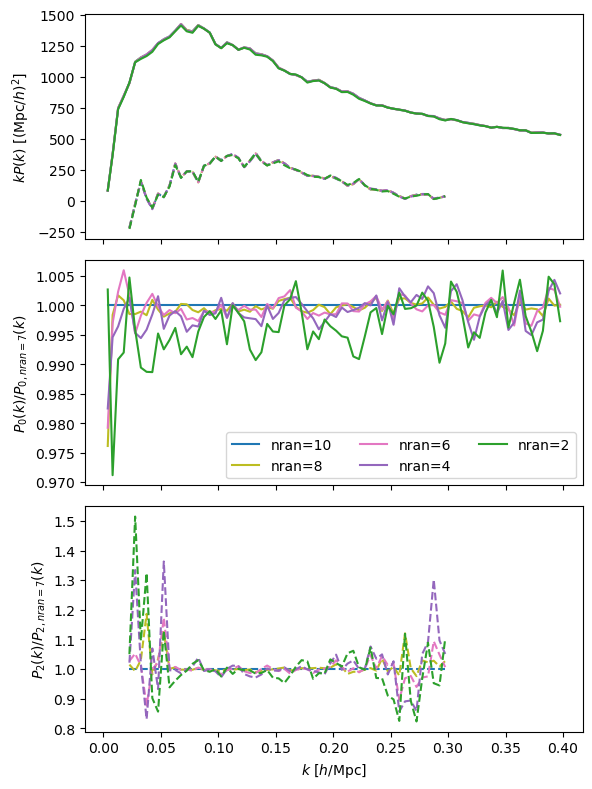

In [18]:
fig, axs = plt.subplots(3,1, figsize=(6,8), sharex=True, height_ratios=[1,1,1])
for nran in range(10,0,-2):
    recon_ps_fn = get_stats_fn(stats_dir=stats_dir, kind='recon_mesh2_spectrum', version=mock_ver, imock=imock, weight=weight, tracer=tracer, zrange=zbins, region=region, extra=f'nran{nran}')
    print(recon_ps_fn)
    spectrum = types.read(recon_ps_fn)
    # print(spectrum, f"with k-average: {spectrum.get(ells=0).coords('k')}")
    spectrum = spectrum.select(k=slice(0, None, 5))  # rebin to dk = 0.005 h/Mpc
    spectrum = spectrum.select(k=(0., 0.4))  # select k-range
    spectrum = spectrum.get(ells=[0, 2])  # monopole and quadrupole
    spectrum = spectrum.at(ells=[2]).select(k=(0.02, 0.3))  # apply stricter k-cut to the quadrupole

    if nran==10:
        poles0 = []
    for i, ell in enumerate(spectrum.ells):
        pole = spectrum.get(ell)
        k=pole.coords('k')
        axs[0].plot(k, k*pole.value(), color=f'C{nran}', linestyle=['-', '--'][i])
        if nran==10:
            poles0.append(pole.value())
        axs[i+1].plot(k, pole.value()/poles0[i], color=f'C{nran}', linestyle=['-', '--'][i], label=f'nran={nran}')

        # pole.coords('k')  # k-modes
        # pole.value()  # value of the power spectrum multipole

            #print(pole.values('shotnoise'))  # shotnoise
    # spectrum.plot(show=True)
axs[0].set_ylabel(r'$k P(k)$ [$(\mathrm{Mpc}/h)^2$]')
axs[1].set_ylabel(r'$P_0(k)/P_{0,nran=7}(k)$')
axs[2].set_ylabel(r'$P_2(k)/P_{2,nran=7}(k)$')
axs[2].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
axs[1].legend(ncol=3)
fig.tight_layout()
# ax=fig.get_axes()[0]
# ax.set_ylim(0,5000)
# fig.show()

In [5]:
nran = 18
cellsize_dict  = {'ELG_LOPnotqso':7.8, 'LRG':7.8, 'QSO':7.8}
boxsize_list_dict = {'ELG_LOPnotqso':[6000,7000,8000,9000,10000], 
                     'LRG':[5000,6000,7000,8000,9000,10000],
                     'QSO':[7000,8000,9000,10000]}
zrange_dict       = {'ELG_LOPnotqso':[(0.8,1.1)], 
                     'LRG':[(0.4,0.6),(0.6,0.8),(0.8,1.1)], 
                     'QSO':[(0.8,2.1)]}
nran_list_dict = {'ELG_LOPnotqso':[10,12,14,16,18],
                     'LRG':[2,4,6,8,10,12,14,16,18], 
                     'QSO':[2,4,6,8,10,12,14,16,18]}
cellsize_list_dict = {'ELG_LOPnotqso':[6, 7.8, 8, 10, 12], 
                     'LRG':[7.8, 8, 10, 12], 
                     'QSO':[7.8, 8, 10, 12]}

In [10]:
from clustering_statistics.tools import combine_stats, write_stats

def combine_regions_to_GCcomb(kinds, tracer, zbins, mock_ver, imock, weight, extra='', extra_comb='',
                               stats_dir=stats_dir, regions=['NGC', 'SGC'], reg_comb='GCcomb'):
    for kind in kinds:
        fn_comb = get_stats_fn(stats_dir=stats_dir, kind=kind, version=mock_ver, imock=imock,
                               weight=weight, tracer=tracer, zrange=zbins, region=reg_comb, extra=extra_comb)
        fns = [get_stats_fn(stats_dir=stats_dir, kind=kind, version=mock_ver, imock=imock,
                            weight=weight, tracer=tracer, zrange=zbins, region=reg, extra=extra)
               for reg in regions]
        missing = [fn for fn in fns if not fn.exists()]
        if missing:
            print(f'[SKIP] {kind} {reg_comb}: missing {missing}')
            continue
        combined = combine_stats([types.read(fn) for fn in fns])
        write_stats(fn_comb, combined)
        print(f'[DONE] {kind}: wrote {fn_comb}')


In [11]:
kinds = ['recon_mesh2_spectrum', 'recon_particle2_correlation']
tracer = 'ELG_LOPnotqso'
zbins = (0.8, 1.1)
weight = 'default-FKP'
mock_ver = 'holi-v1-altmtl'
imock = 451
for boxsize in boxsize_list_dict[tracer]:
    nran = 18
    cellsize = cellsize_dict[tracer]
    extra = f'boxsize{boxsize}'
    extra_comb = f'nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize:d}'
    combine_regions_to_GCcomb(
        kinds=kinds,
        tracer=tracer, zbins=zbins,
        mock_ver=mock_ver, imock=imock, weight=weight,
        extra=extra, extra_comb=extra_comb,
    )
for nran in [2, 4, 6, 8, 10, 12, 14, 16]:
    cellsize = cellsize_dict[tracer]
    boxsize = boxsize_list_dict[tracer][-1]
    extra = f'nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize:d}'
    extra_comb = extra
    combine_regions_to_GCcomb(
        kinds=kinds,
        tracer=tracer, zbins=zbins,
        mock_ver=mock_ver, imock=imock, weight=weight,
        extra=extra, extra_comb=extra_comb,
    )
for cellsize in [6,8,10,12]:
    nran = 18
    boxsize = 6000
    extra = f'nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize:d}'
    extra_comb = extra
    combine_regions_to_GCcomb(
        kinds=kinds,
        tracer=tracer, zbins=zbins,
        mock_ver=mock_ver, imock=imock, weight=weight,
        extra=extra, extra_comb=extra_comb,
    )
for imock in range(451, 461):
    nran = 18
    cellsize = 7.8
    boxsize = boxsize_list_dict[tracer][-1]
    extra = f'nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize:d}'
    extra_comb = extra
    combine_regions_to_GCcomb(
        kinds=kinds,
        tracer=tracer, zbins=zbins,
        mock_ver=mock_ver, imock=imock, weight=weight,
        extra=extra, extra_comb=extra_comb,
    )

[DONE] recon_mesh2_spectrum: wrote /pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_poles_ELG_LOPnotqso_z0.8-1.1_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize6000_451.h5
[DONE] recon_particle2_correlation: wrote /pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_smu_ELG_LOPnotqso_z0.8-1.1_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize6000_451.h5
[DONE] recon_mesh2_spectrum: wrote /pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_poles_ELG_LOPnotqso_z0.8-1.1_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize7000_451.h5
[DONE] recon_particle2_correlation: wrote /pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_smu_ELG_LOPnotqso_z0.8-1.1_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize7000_451.h5
[DONE] recon_mesh2_spectrum: wrote /pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v

  0%|          | 0/1 [00:00<?, ?it/s]

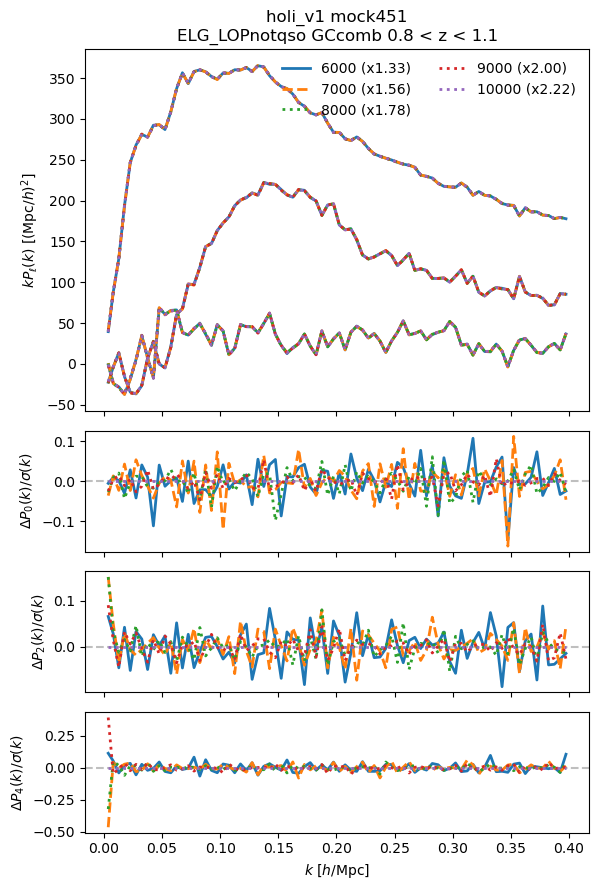

100%|██████████| 1/1 [00:02<00:00,  2.49s/it]


In [35]:
mock_version = "holi_v1"
pk4cov_dir = "/pscratch/sd/a/arosado/cai-dr2-benchmarks/randoms_checks/"
# base_dir   = "/pscratch/sd/a/arosado/cai-dr2-benchmarks/old_boxsize_checks/"
cai_dir    = "/global/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v1/"

tracer = 'ELG_LOPnotqso'
weight_type = weight_type2 = 'default_FKP'
regions = labels = ['GCcomb'] #code below only works for GCcomb
ls = ['-','--',':',':',':',':']
tracers = ['ELG_LOPnotqso']#,'LRG','QSO'
mocks_list = [451]
ells = [0,2,4]
lw = 2

for mocki in tqdm(mocks_list):
    pk_dir = stats_dir / "holi-v1-altmtl"
    output_fn_args = dict(base_dir=stats_dir, kind='recon_mesh2_spectrum_poles', file_type='h5')
    for tracer in tracers:
        data_fn  = [cai_dir + f"/altmtl{mocki}/loa-v1/mock{mocki}/LSScats/{tracer}_{reg}_clustering.dat.h5" for reg in ['NGC','SGC']] 
        data_full = Catalog.read(data_fn[0],group='LSS')
        data_full.append(Catalog.read(data_fn[1],group='LSS'))
        
        z_bins = zrange_dict[tracer]
        ncols = len(z_bins)

        height_ratios = [max(len(ells), 3)] + [1] * len(ells)
        figsize = (6 * ncols, 1.5 * sum(height_ratios))

        fig, lax = plt.subplots(len(height_ratios), ncols,sharex='col',gridspec_kw={'height_ratios': height_ratios},
                                figsize=figsize,squeeze=False)
        fig.subplots_adjust(hspace=0.1, wspace=0.15)
        boxsize_list = boxsize_list_dict[tracer]
        for iz, (zmin, zmax) in enumerate(z_bins):
            mask = (data_full['Z'] >= zmin) & ( data_full['Z'] <= zmax)
            data = data_full[mask]
            min_boxsize = get_min_boxsize(data)
            
            stats = {str(ibox): {} for ibox in boxsize_list}
            
            # get dispersion from mocks
            mocks4cov_list = [i for i in range(451,461)]
            mocks4cov_list.pop(5)
            fns = [pk_dir / f"recon_mesh2_spectrum_poles_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize10000_{mocki}.h5" for mocki in mocks4cov_list] 
            pks = [read(fn).select(k=slice(0, None, 5)) for fn in fns]
            std_dict = {str(ell): np.std([pks[i].get(ell).value().real for i in range(len(mocks4cov_list))],axis=0) for ell in ells}
            
            for icolor, boxsize in enumerate(boxsize_list):
                # for region in regions:
                fn = pk_dir / f"recon_mesh2_spectrum_poles_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize{boxsize}_{mocki}.h5"
                ref = read(fn).select(k=slice(0, None, 5))
                ax = lax[0, iz]
                ax.set_title(f'{mock_version} mock{mocki}\n{tracer} {regions[0]} {zmin:.1f} < z < {zmax:.1f}')
                ax.set_ylabel(rf'$k P_\ell(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                for ill, ell in enumerate(ells):
                    pole = ref.get(ell)
                    value = pole.value().real
                    ax.plot(pole.coords('k'), pole.coords('k') * value, linestyle=ls[icolor], color=f"C{icolor}",lw=lw)
                    stats[str(boxsize)][str(ell)] = value

            for icolor, boxsize in enumerate(boxsize_list):
                ax.plot([], [],linestyle=ls[icolor],color=f"C{icolor}",lw=lw,label=f"{boxsize} (x{boxsize/np.max(min_boxsize):.2f})")
            # if iz == 0:
            ax.legend(frameon=False, ncol=2)

            for ill, ell in enumerate(ells):
                ax = lax[ill + 1, iz]
                ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
                ax.set_ylabel(rf'$\Delta P_{ell}(k)/\sigma(k)$')
                
                value_bench = stats['10000'][str(ell)]

                for icolor, boxsize in enumerate(boxsize_list):
                    value = stats[str(boxsize)][str(ell)]
                    ax.plot(pole.coords('k'), (value_bench-value)/std_dict[str(ell)], linestyle=ls[icolor], color=f"C{icolor}",lw=lw)
                    
            lax[-1, iz].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')

        plt.tight_layout()
        #fig.savefig(f'plots_tests/test_boxsizes_{tracer}.png', bbox_inches='tight', pad_inches=0.1, dpi=200)
        plt.show()


  0%|          | 0/1 [00:00<?, ?it/s]

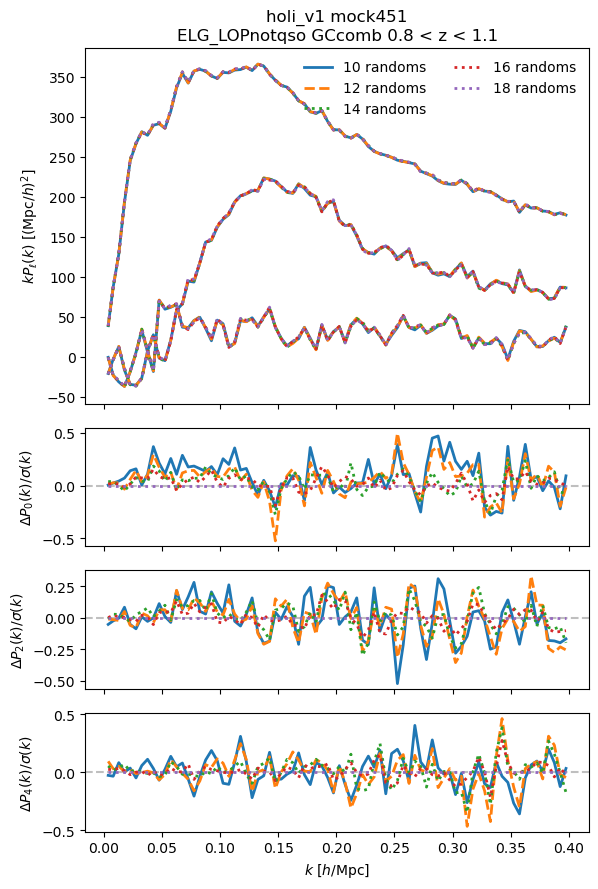

100%|██████████| 1/1 [00:01<00:00,  1.14s/it]


In [44]:
# Check nran
mock_version = "holi_v1"
pk4cov_dir = "/pscratch/sd/a/arosado/cai-dr2-benchmarks/randoms_checks/"
# base_dir   = "/pscratch/sd/a/arosado/cai-dr2-benchmarks/old_boxsize_checks/"
cai_dir    = "/global/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v1/"

tracer = 'ELG_LOPnotqso'
weight_type = weight_type2 = 'default_FKP'
regions = labels = ['GCcomb'] #code below only works for GCcomb
ls = ['-','--',':',':',':',':',':',':',':',':']
tracers = ['ELG_LOPnotqso']#,'LRG','QSO'
mocks_list = [451]
ells = [0,2,4]
lw = 2
boxsize = 10000
cellsize = 7.8

for mocki in tqdm(mocks_list):
    pk_dir = stats_dir / "holi-v1-altmtl"
    output_fn_args = dict(base_dir=stats_dir, kind='recon_mesh2_spectrum_poles', file_type='h5')
    for tracer in tracers:
        
        
        z_bins = zrange_dict[tracer]
        ncols = len(z_bins)

        height_ratios = [max(len(ells), 3)] + [1] * len(ells)
        figsize = (6 * ncols, 1.5 * sum(height_ratios))

        fig, lax = plt.subplots(len(height_ratios), ncols,sharex='col',gridspec_kw={'height_ratios': height_ratios},
                                figsize=figsize,squeeze=False)
        fig.subplots_adjust(hspace=0.1, wspace=0.15)
        nran_list = nran_list_dict[tracer]
        for iz, (zmin, zmax) in enumerate(z_bins):
            
            stats = {str(nran): {} for nran in nran_list}
            
            # get dispersion from mocks
            mocks4cov_list = [i for i in range(451,461)]
            mocks4cov_list.pop(5)
            fns = [pk_dir / f"recon_mesh2_spectrum_poles_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize10000_{mocki}.h5" for mocki in mocks4cov_list] 
            pks = [read(fn).select(k=slice(0, None, 5)) for fn in fns]
            std_dict = {str(ell): np.std([pks[i].get(ell).value().real for i in range(len(mocks4cov_list))],axis=0) for ell in ells}
            
            for icolor, nran in enumerate(nran_list):
                # for region in regions:
                fn = pk_dir / f"recon_mesh2_spectrum_poles_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize}_{mocki}.h5"
                ref = read(fn).select(k=slice(0, None, 5))
                ax = lax[0, iz]
                ax.set_title(f'{mock_version} mock{mocki}\n{tracer} {regions[0]} {zmin:.1f} < z < {zmax:.1f}')
                ax.set_ylabel(rf'$k P_\ell(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                for ill, ell in enumerate(ells):
                    pole = ref.get(ell)
                    value = pole.value().real
                    ax.plot(pole.coords('k'), pole.coords('k') * value, linestyle=ls[icolor], color=f"C{icolor}",lw=lw)
                    stats[str(nran)][str(ell)] = value

            for icolor, nran in enumerate(nran_list):
                ax.plot([], [],linestyle=ls[icolor],color=f"C{icolor}",lw=lw,label=f"{nran} randoms")
            # if iz == 0:
            ax.legend(frameon=False, ncol=2)

            for ill, ell in enumerate(ells):
                ax = lax[ill + 1, iz]
                ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
                ax.set_ylabel(rf'$\Delta P_{ell}(k)/\sigma(k)$')
                
                value_bench = stats['18'][str(ell)]

                for icolor, nran in enumerate(nran_list):
                    value = stats[str(nran)][str(ell)]
                    ax.plot(pole.coords('k'), (value_bench-value)/std_dict[str(ell)], linestyle=ls[icolor], color=f"C{icolor}",lw=lw)
                    
            lax[-1, iz].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')

        plt.tight_layout()
        #fig.savefig(f'plots_tests/test_boxsizes_{tracer}.png', bbox_inches='tight', pad_inches=0.1, dpi=200)
        plt.show()


  0%|          | 0/1 [00:00<?, ?it/s]

cellsize=7.80, ell=0: len(pole.coords('k'))=80, len(value)=80
cellsize=7.80, ell=2: len(pole.coords('k'))=80, len(value)=80
cellsize=7.80, ell=4: len(pole.coords('k'))=80, len(value)=80
cellsize=8.00, ell=0: len(pole.coords('k'))=78, len(value)=78
cellsize=8.00, ell=2: len(pole.coords('k'))=78, len(value)=78
cellsize=8.00, ell=4: len(pole.coords('k'))=78, len(value)=78


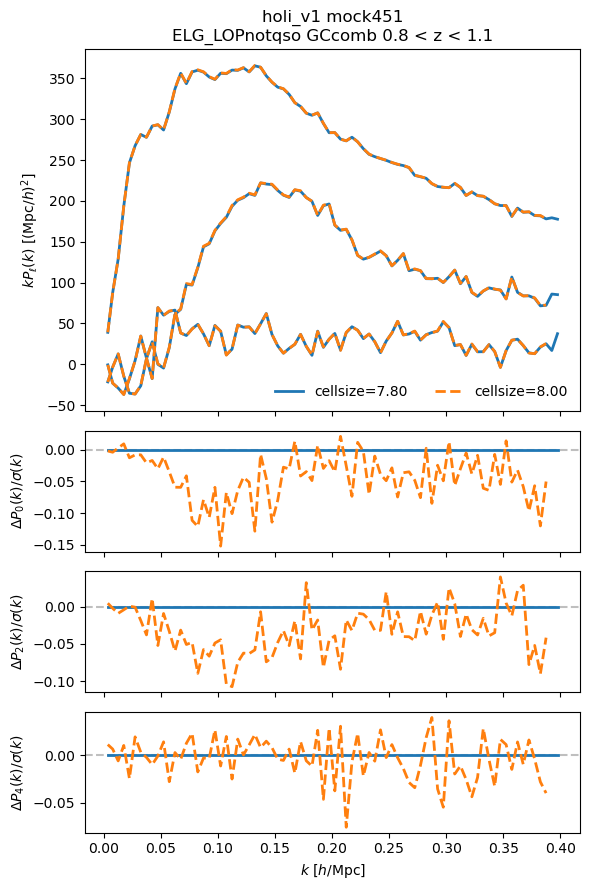

100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


In [55]:
# Check cellsize
mock_version = "holi_v1"
pk4cov_dir = "/pscratch/sd/a/arosado/cai-dr2-benchmarks/randoms_checks/"
# base_dir   = "/pscratch/sd/a/arosado/cai-dr2-benchmarks/old_boxsize_checks/"
cai_dir    = "/global/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v1/"

tracer = 'ELG_LOPnotqso'
weight_type = weight_type2 = 'default_FKP'
regions = labels = ['GCcomb'] #code below only works for GCcomb
ls = ['-','--',':',':',':',':',':',':',':',':']
tracers = ['ELG_LOPnotqso']#,'LRG','QSO'
mocks_list = [451]
ells = [0,2,4]
lw = 2
boxsize = 10000
nran = 18
cellsize_list = cellsize_list_dict[tracer][:2]

for mocki in tqdm(mocks_list):
    pk_dir = stats_dir / "holi-v1-altmtl"
    output_fn_args = dict(base_dir=stats_dir, kind='recon_mesh2_spectrum_poles', file_type='h5')
    for tracer in tracers:
        
        
        z_bins = zrange_dict[tracer]
        ncols = len(z_bins)

        height_ratios = [max(len(ells), 3)] + [1] * len(ells)
        figsize = (6 * ncols, 1.5 * sum(height_ratios))

        fig, lax = plt.subplots(len(height_ratios), ncols,sharex='col',gridspec_kw={'height_ratios': height_ratios},
                                figsize=figsize,squeeze=False)
        fig.subplots_adjust(hspace=0.1, wspace=0.15)
        for iz, (zmin, zmax) in enumerate(z_bins):
            
            stats = {}
            
            # get dispersion from mocks
            mocks4cov_list = [i for i in range(451,461)]
            mocks4cov_list.pop(5)
            fns = [pk_dir / f"recon_mesh2_spectrum_poles_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize10000_{mocki}.h5" for mocki in mocks4cov_list] 
            pks = [read(fn).select(k=slice(0, None, 5)) for fn in fns]
            std_dict = {str(ell): np.std([pks[i].get(ell).value().real for i in range(len(mocks4cov_list))],axis=0) for ell in ells}
            
            available_cellsizes = []
            for icolor, cellsize in enumerate(cellsize_list):
                fn = pk_dir / f"recon_mesh2_spectrum_poles_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize}_{mocki}.h5"
                if not fn.exists():
                    print(f'[SKIP] cellsize={cellsize:.2f}: {fn.name} not found')
                    continue
                ref = read(fn).select(k=slice(0, None, 5))
                ax = lax[0, iz]
                ax.set_title(f'{mock_version} mock{mocki}\n{tracer} {regions[0]} {zmin:.1f} < z < {zmax:.1f}')
                ax.set_ylabel(rf'$k P_\ell(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                stats[str(cellsize)] = {}
                for ill, ell in enumerate(ells):
                    pole = ref.get(ell)
                    value = pole.value().real
                    ax.plot(pole.coords('k'), pole.coords('k') * value, linestyle=ls[icolor], color=f"C{icolor}",lw=lw)
                    print(f"cellsize={cellsize:.2f}, ell={ell}: len(pole.coords('k'))={len(pole.coords('k'))}, len(value)={len(value)}")
                    stats[str(cellsize)][str(ell)] = (pole.coords('k'), value)
                available_cellsizes.append((icolor, cellsize))

            for icolor, cellsize in available_cellsizes:
                ax.plot([], [],linestyle=ls[icolor],color=f"C{icolor}",lw=lw,label=f"cellsize={cellsize:.2f}")
            ax.legend(frameon=False, ncol=2)

            bench_key = '7.8'
            if bench_key not in stats:
                print(f'[WARN] benchmark cellsize={bench_key} not available, skipping ratio plots')
            else:
                for ill, ell in enumerate(ells):
                    ax = lax[ill + 1, iz]
                    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
                    ax.set_ylabel(rf'$\Delta P_{ell}(k)/\sigma(k)$')
                    k_bench, value_bench = stats[bench_key][str(ell)]
                    for icolor, cellsize in available_cellsizes:
                        k, value = stats[str(cellsize)][str(ell)]
                        value_interp = np.interp(k, k_bench, value_bench)
                        std_interp = np.interp(k, k_bench, std_dict[str(ell)])  
                        ax.plot(k, (value_interp-value)/std_interp, linestyle=ls[icolor], color=f"C{icolor}",lw=lw)
                    
            lax[-1, iz].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')

        plt.tight_layout()
        #fig.savefig(f'plots_tests/test_boxsizes_{tracer}.png', bbox_inches='tight', pad_inches=0.1, dpi=200)
        plt.show()


  0%|          | 0/1 [00:00<?, ?it/s]

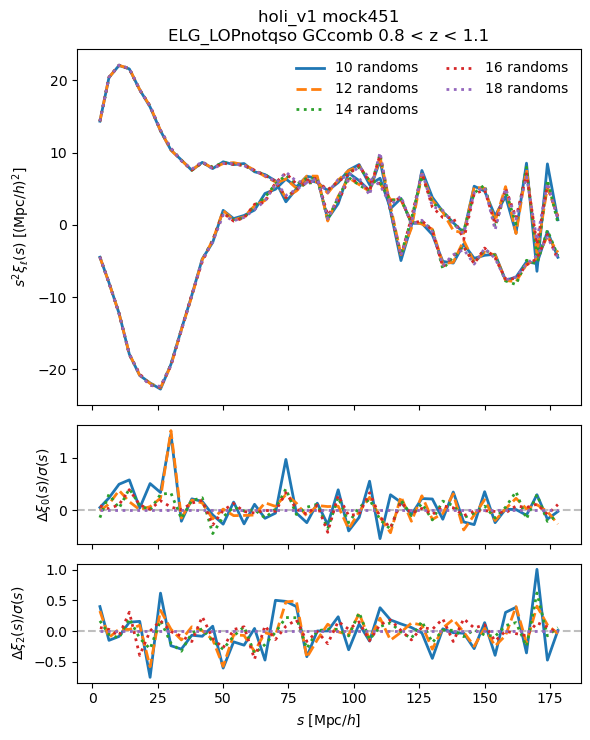

100%|██████████| 1/1 [00:02<00:00,  2.14s/it]


In [59]:
# Check nran - correlation function
mock_version = "holi_v1"
tracer = 'ELG_LOPnotqso'
ls = ['-','--',':',':',':',':',':',':',':',':']
tracers = ['ELG_LOPnotqso']
mocks_list = [451]
ells = [0, 2]
lw = 2
boxsize = 10000
cellsize = 7.8

for mocki in tqdm(mocks_list):
    cf_dir = stats_dir / "holi-v1-altmtl"
    for tracer in tracers:
        z_bins = zrange_dict[tracer]
        ncols = len(z_bins)
        height_ratios = [max(len(ells), 3)] + [1] * len(ells)
        figsize = (6 * ncols, 1.5 * sum(height_ratios))
        fig, lax = plt.subplots(len(height_ratios), ncols, sharex='col',
                                gridspec_kw={'height_ratios': height_ratios},
                                figsize=figsize, squeeze=False)
        fig.subplots_adjust(hspace=0.1, wspace=0.15)
        nran_list = nran_list_dict[tracer]
        for iz, (zmin, zmax) in enumerate(z_bins):
            stats = {}

            # get dispersion from mocks
            mocks4cov_list = list(range(451, 461))
            mocks4cov_list.pop(5)
            fns_ref = [cf_dir / f"recon_particle2_correlation_smu_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran18_cellsize{cellsize:.2f}_boxsize{boxsize}_{mk}.h5"
                       for mk in mocks4cov_list]
            cfs_ref = [read(fn).select(s=slice(0, None, 4)).project(ells=ells) for fn in fns_ref if fn.exists()]
            s_ref = read(fns_ref[0]).select(s=slice(0, None, 4)).coords('s')
            std_dict = {str(ell): np.std([cf.get(ell).value().real for cf in cfs_ref], axis=0) for ell in ells}

            available_nrans = []
            for icolor, nran in enumerate(nran_list):
                fn = cf_dir / f"recon_particle2_correlation_smu_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize}_{mocki}.h5"
                if not fn.exists():
                    print(f'[SKIP] nran={nran}: {fn.name} not found')
                    continue
                corr = read(fn).select(s=slice(0, None, 4))
                
                xi = corr.project(ells=ells)
                s = corr.coords('s')
                ax = lax[0, iz]
                ax.set_title(f'{mock_version} mock{mocki}\n{tracer} GCcomb {zmin:.1f} < z < {zmax:.1f}')
                ax.set_ylabel(r'$s^2 \xi_\ell(s)$ [$(\mathrm{Mpc}/h)^2$]')
                stats[str(nran)] = {}
                for ill, ell in enumerate(ells):
                    pole = xi.get(ell)
                    value = pole.value().real
                    ax.plot(s, s**2 * value, linestyle=ls[icolor], color=f"C{icolor}", lw=lw)
                    stats[str(nran)][str(ell)] = (s, value)
                available_nrans.append((icolor, nran))

            for icolor, nran in available_nrans:
                ax.plot([], [], linestyle=ls[icolor], color=f"C{icolor}", lw=lw, label=f"{nran} randoms")
            ax.legend(frameon=False, ncol=2)

            bench_key = '18'
            if bench_key not in stats:
                print(f'[WARN] benchmark nran={bench_key} not available, skipping ratio plots')
            else:
                for ill, ell in enumerate(ells):
                    ax = lax[ill + 1, iz]
                    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
                    ax.set_ylabel(rf'$\Delta \xi_{ell}(s)/\sigma(s)$')
                    s_bench, value_bench = stats[bench_key][str(ell)]
                    for icolor, nran in available_nrans:
                        s, value = stats[str(nran)][str(ell)]
                        value_interp = np.interp(s_bench, s, value)
                        std_interp = np.interp(s_bench, s_ref, std_dict[str(ell)])
                        ax.plot(s_bench, (value_bench - value_interp) / std_interp,
                                linestyle=ls[icolor], color=f"C{icolor}", lw=lw)

            lax[-1, iz].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')

        plt.tight_layout()
        plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

[SKIP] cellsize=10.00: recon_particle2_correlation_smu_ELG_LOPnotqso_z0.8-1.1_GCcomb_weight-default-FKP_nran18_cellsize10.00_boxsize6000_451.h5 not found
[SKIP] cellsize=12.00: recon_particle2_correlation_smu_ELG_LOPnotqso_z0.8-1.1_GCcomb_weight-default-FKP_nran18_cellsize12.00_boxsize6000_451.h5 not found
dict_keys(['6', '7.8', '8'])
{'0': (array([ 60.1670553 ,  68.14650974,  76.13013153,  84.11695149,
        92.10609348, 100.09696994, 108.08925022, 116.08263052,
       124.07682599, 132.07169359, 140.06703453, 148.06285337]), array([ 2.17079794e-03,  1.38104234e-03,  7.78260750e-04,  8.37257962e-04,
        6.35692125e-04,  7.40277161e-04,  5.09966663e-04,  2.53451477e-04,
        2.15544998e-05, -1.90039058e-04, -1.90776602e-04, -1.98099657e-04])), '2': (array([ 60.1670553 ,  68.14650974,  76.13013153,  84.11695149,
        92.10609348, 100.09696994, 108.08925022, 116.08263052,
       124.07682599, 132.07169359, 140.06703453, 148.06285337]), array([ 4.34531625e-04,  9.66512187e-04,

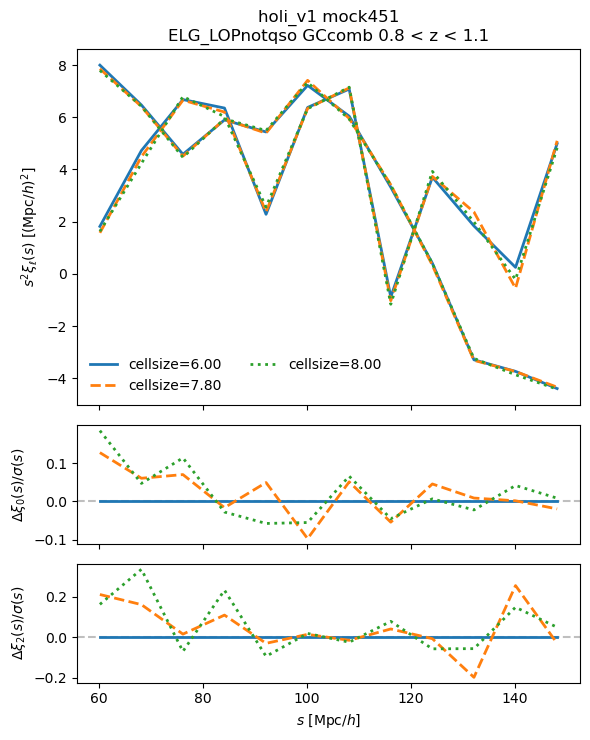

100%|██████████| 1/1 [00:08<00:00,  8.22s/it]


In [22]:
# Check cellsize - correlation function
mock_version = "holi_v1"
tracer = 'ELG_LOPnotqso'
ls = ['-','--',':',':',':',':',':',':',':',':']
tracers = ['ELG_LOPnotqso']
mocks_list = [451]
ells = [0, 2]
lw = 2
boxsize = 6000
nran = 18
cellsize_list = cellsize_list_dict[tracer]

for mocki in tqdm(mocks_list):
    cf_dir = stats_dir / "holi-v1-altmtl"
    for tracer in tracers:
        z_bins = zrange_dict[tracer]
        ncols = len(z_bins)
        height_ratios = [max(len(ells), 3)] + [1] * len(ells)
        figsize = (6 * ncols, 1.5 * sum(height_ratios))
        fig, lax = plt.subplots(len(height_ratios), ncols, sharex='col',
                                gridspec_kw={'height_ratios': height_ratios},
                                figsize=figsize, squeeze=False)
        fig.subplots_adjust(hspace=0.1, wspace=0.15)
        for iz, (zmin, zmax) in enumerate(z_bins):
            stats = {}

            # get dispersion from mocks
            mocks4cov_list = list(range(451, 461))
            mocks4cov_list.pop(5)
            fns_ref = [cf_dir / f"recon_particle2_correlation_smu_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran18_cellsize7.80_boxsize10000_{mk}.h5"
                       for mk in mocks4cov_list]
            cfs_ref = [read(fn).select(s=slice(0, None, 8)).project(ells=ells) for fn in fns_ref if fn.exists()]
            s_ref = read(fns_ref[0]).select(s=slice(0, None, 8)).coords('s')
            std_dict = {str(ell): np.std([cf.get(ell).value().real for cf in cfs_ref], axis=0) for ell in ells}

            available_cellsizes = []
            for icolor, cellsize in enumerate(cellsize_list):
                fn = cf_dir / f"recon_particle2_correlation_smu_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize}_{mocki}.h5"
                if not fn.exists():
                    print(f'[SKIP] cellsize={cellsize:.2f}: {fn.name} not found')
                    continue
                corr = read(fn).select(s=slice(0, None, 8))
                # cut to s in [60,150] Mpc/h
                corr = corr.select(s=(60, 150))
                xi = corr.project(ells=ells)
                s = corr.coords('s')
                ax = lax[0, iz]
                ax.set_title(f'{mock_version} mock{mocki}\n{tracer} GCcomb {zmin:.1f} < z < {zmax:.1f}')
                ax.set_ylabel(r'$s^2 \xi_\ell(s)$ [$(\mathrm{Mpc}/h)^2$]')
                stats[str(cellsize)] = {}
                for ill, ell in enumerate(ells):
                    pole = xi.get(ell)
                    value = pole.value().real
                    ax.plot(s, s**2 * value, linestyle=ls[icolor], color=f"C{icolor}", lw=lw)
                    stats[str(cellsize)][str(ell)] = (s, value)
                available_cellsizes.append((icolor, cellsize))

            for icolor, cellsize in available_cellsizes:
                ax.plot([], [], linestyle=ls[icolor], color=f"C{icolor}", lw=lw, label=f"cellsize={cellsize:.2f}")
            ax.legend(frameon=False, ncol=2)

            print(stats.keys())
            print(stats['7.8'])
            
            bench_key = '6'
            if bench_key not in stats:
                print(f'[WARN] benchmark cellsize={bench_key} not available, skipping ratio plots')
            else:
                for ill, ell in enumerate(ells):
                    ax = lax[ill + 1, iz]
                    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
                    ax.set_ylabel(rf'$\Delta \xi_{ell}(s)/\sigma(s)$')
                    s_bench, value_bench = stats[bench_key][str(ell)]
                    for icolor, cellsize in available_cellsizes:
                        s, value = stats[str(cellsize)][str(ell)]
                        value_interp = np.interp(s_bench, s, value)
                        std_interp = np.interp(s_bench, s_ref, std_dict[str(ell)])
                        ax.plot(s_bench, (value_bench - value_interp) / std_interp,
                                linestyle=ls[icolor], color=f"C{icolor}", lw=lw)

            lax[-1, iz].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')

        plt.tight_layout()
        plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

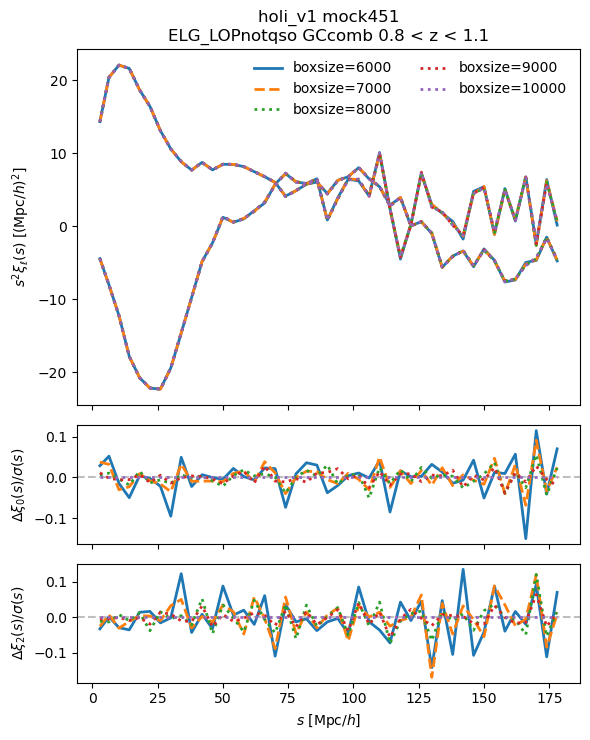

100%|██████████| 1/1 [00:02<00:00,  2.54s/it]


In [62]:
# Check boxsize - correlation function
mock_version = "holi_v1"
tracer = 'ELG_LOPnotqso'
ls = ['-','--',':',':',':',':']
tracers = ['ELG_LOPnotqso']
mocks_list = [451]
ells = [0, 2]
lw = 2
cellsize = 7.8
nran = 18

for mocki in tqdm(mocks_list):
    cf_dir = stats_dir / "holi-v1-altmtl"
    for tracer in tracers:
        z_bins = zrange_dict[tracer]
        ncols = len(z_bins)
        height_ratios = [max(len(ells), 3)] + [1] * len(ells)
        figsize = (6 * ncols, 1.5 * sum(height_ratios))
        fig, lax = plt.subplots(len(height_ratios), ncols, sharex='col',
                                gridspec_kw={'height_ratios': height_ratios},
                                figsize=figsize, squeeze=False)
        fig.subplots_adjust(hspace=0.1, wspace=0.15)
        boxsize_list = boxsize_list_dict[tracer]
        for iz, (zmin, zmax) in enumerate(z_bins):
            stats = {}

            # get dispersion from mocks
            mocks4cov_list = list(range(451, 461))
            mocks4cov_list.pop(5)
            fns_ref = [cf_dir / f"recon_particle2_correlation_smu_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran18_cellsize{cellsize:.2f}_boxsize{boxsize_list[-1]}_{mk}.h5"
                       for mk in mocks4cov_list]
            cfs_ref = [read(fn).select(s=slice(0, None, 4)).project(ells=ells) for fn in fns_ref if fn.exists()]
            s_ref = read(fns_ref[0]).select(s=slice(0, None, 4)).coords('s')
            std_dict = {str(ell): np.std([cf.get(ell).value().real for cf in cfs_ref], axis=0) for ell in ells}

            available_boxsizes = []
            for icolor, boxsize in enumerate(boxsize_list):
                fn = cf_dir / f"recon_particle2_correlation_smu_{tracer}_z{zmin}-{zmax}_GCcomb_weight-default-FKP_nran{nran:d}_cellsize{cellsize:.2f}_boxsize{boxsize}_{mocki}.h5"
                if not fn.exists():
                    print(f'[SKIP] boxsize={boxsize}: {fn.name} not found')
                    continue
                corr = read(fn).select(s=slice(0, None, 4))
                xi = corr.project(ells=ells)
                s = corr.coords('s')
                ax = lax[0, iz]
                ax.set_title(f'{mock_version} mock{mocki}\n{tracer} GCcomb {zmin:.1f} < z < {zmax:.1f}')
                ax.set_ylabel(r'$s^2 \xi_\ell(s)$ [$(\mathrm{Mpc}/h)^2$]')
                stats[str(boxsize)] = {}
                for ill, ell in enumerate(ells):
                    pole = xi.get(ell)
                    value = pole.value().real
                    ax.plot(s, s**2 * value, linestyle=ls[icolor], color=f"C{icolor}", lw=lw)
                    stats[str(boxsize)][str(ell)] = (s, value)
                available_boxsizes.append((icolor, boxsize))

            for icolor, boxsize in available_boxsizes:
                ax.plot([], [], linestyle=ls[icolor], color=f"C{icolor}", lw=lw, label=f"boxsize={boxsize}")
            ax.legend(frameon=False, ncol=2)

            bench_key = str(boxsize_list[-1])
            if bench_key not in stats:
                print(f'[WARN] benchmark boxsize={bench_key} not available, skipping ratio plots')
            else:
                for ill, ell in enumerate(ells):
                    ax = lax[ill + 1, iz]
                    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
                    ax.set_ylabel(rf'$\Delta \xi_{ell}(s)/\sigma(s)$')
                    s_bench, value_bench = stats[bench_key][str(ell)]
                    for icolor, boxsize in available_boxsizes:
                        s, value = stats[str(boxsize)][str(ell)]
                        value_interp = np.interp(s_bench, s, value)
                        std_interp = np.interp(s_bench, s_ref, std_dict[str(ell)])
                        ax.plot(s_bench, (value_bench - value_interp) / std_interp,
                                linestyle=ls[icolor], color=f"C{icolor}", lw=lw)

            lax[-1, iz].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')

        plt.tight_layout()
        plt.show()

In [6]:
# check the catalog
region = 'NGC'
tracer = 'LRG'
zrange = 'z0.4-0.6'
jax_recon_dat_fn = stats_dir / f'jax_recon_{tracer}_{zrange}_{region}_clustering.dat.h5'
jax_recon_dat = Catalog.read(jax_recon_dat_fn)
pyrecon_dat_fn = stats_dir / f'pyrecon_{tracer}_{zrange}_{region}_clustering.dat.h5'
pyrecon_dat = Catalog.read(pyrecon_dat_fn)

Text(0.5, 1.0, 'Z residuals')

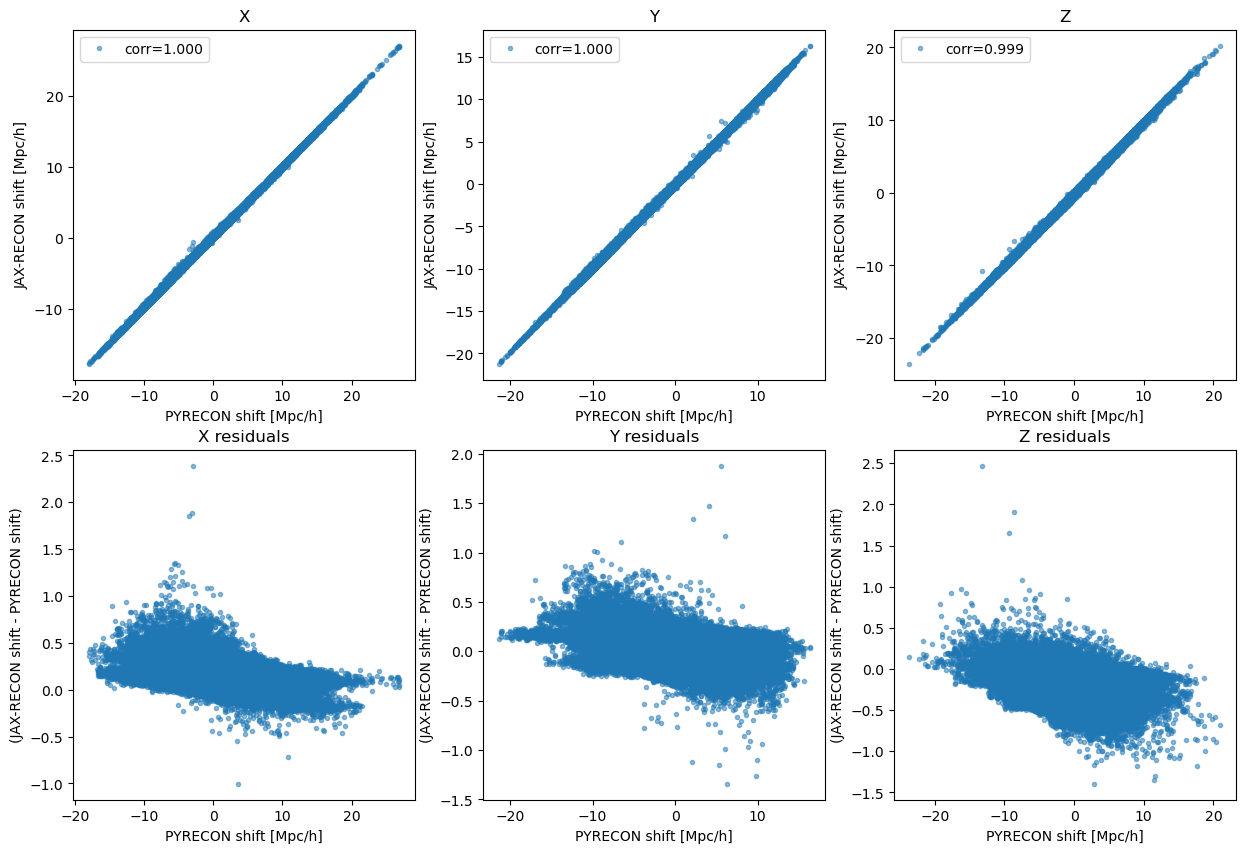

In [7]:
shift_jax = jax_recon_dat['POSITION_REC']-jax_recon_dat['POSITION']
shift_pyrecon = pyrecon_dat['POSITION_REC']-pyrecon_dat['POSITION']
fig, ax = plt.subplots(2,3,figsize=(15,10))
corr_coef = np.corrcoef(shift_jax[:,0], shift_pyrecon[:,0])[0,1]
ax[0,0].plot(shift_pyrecon[:,0], shift_jax[:,0], '.', alpha=0.5, label=f'corr={corr_coef:.3f}')
ax[0,0].set_ylabel('JAX-RECON shift [Mpc/h]')
ax[0,0].set_xlabel('PYRECON shift [Mpc/h]')
ax[0,0].legend()
ax[0,0].set_title('X')
corr_coef = np.corrcoef(shift_jax[:,1], shift_pyrecon[:,1])[0,1]
ax[0,1].plot(shift_pyrecon[:,1], shift_jax[:,1], '.', alpha=0.5, label=f'corr={corr_coef:.3f}')
ax[0,1].set_ylabel('JAX-RECON shift [Mpc/h]')
ax[0,1].set_xlabel('PYRECON shift [Mpc/h]')
ax[0,1].legend()
ax[0,1].set_title('Y')
corr_coef = np.corrcoef(shift_jax[:,2], shift_pyrecon[:,2])[0,1]
ax[0,2].plot(shift_pyrecon[:,2], shift_jax[:,2], '.', alpha=0.5, label=f'corr={corr_coef:.3f}')
ax[0,2].set_ylabel('JAX-RECON shift [Mpc/h]')
ax[0,2].set_xlabel('PYRECON shift [Mpc/h]')
ax[0,2].legend()
ax[0,2].set_title('Z')

# plot residuals
residuals = shift_jax - shift_pyrecon
ax[1,0].plot(shift_pyrecon[:,0], residuals[:,0], '.', alpha=0.5)
ax[1,0].set_ylabel('(JAX-RECON shift - PYRECON shift)')
ax[1,0].set_xlabel('PYRECON shift [Mpc/h]')
ax[1,0].set_title('X residuals')

ax[1,1].plot(shift_pyrecon[:,1], residuals[:,1], '.', alpha=0.5)
ax[1,1].set_ylabel('(JAX-RECON shift - PYRECON shift)')
ax[1,1].set_xlabel('PYRECON shift [Mpc/h]')
ax[1,1].set_title('Y residuals')

ax[1,2].plot(shift_pyrecon[:,2], residuals[:,2], '.', alpha=0.5)
ax[1,2].set_ylabel('(JAX-RECON shift - PYRECON shift)')
ax[1,2].set_xlabel('PYRECON shift [Mpc/h]')
ax[1,2].set_title('Z residuals')



/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran7_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran6_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran5_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran4_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran3_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran2_451.h5


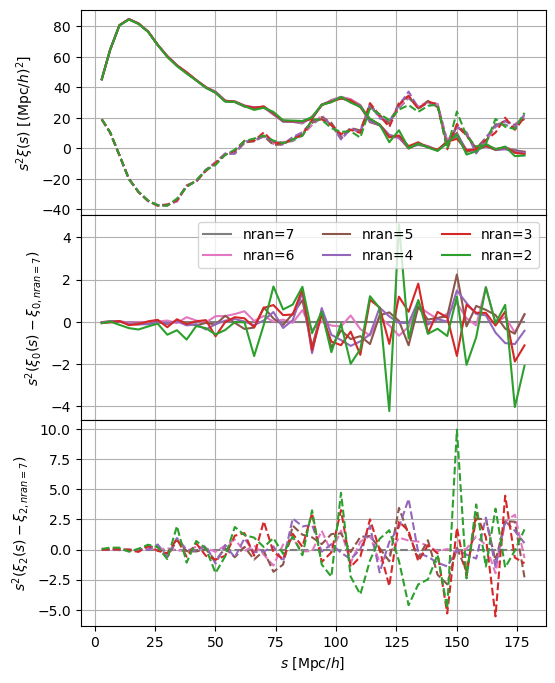

In [86]:
# plot recon correlation function multipoles
mock_ver='holi-v1-altmtl'
imock=451
weight='default-FKP'
tracer='LRG'
zbins=(0.4,0.6)
region='NGC'
fig, axs = plt.subplots(3,1, figsize=(6,8), sharex=True, height_ratios=[1,1,1])
for nran in range(7,1,-1):
    zmin, zmax = zbins
    recon_cf_fn = stats_dir / mock_ver / f'recon_particle2_correlation_{tracer}_z{zmin}-{zmax}_{region}_weight-{weight}_nran{nran}_{imock}.h5'
    corr = types.read(recon_cf_fn)
    print(recon_cf_fn)

    # Rebinning
    corr = corr.select(s=slice(0, None, 4))
    # corr = corr.select(s=(60., 150)) 
    
    # To multipoles
    xi = corr.project(ells=[0, 2])
    s = corr.coords('s')

    if nran==7:
        poles0 = []
    for i, ell in enumerate(xi.ells):
        pole = xi.get(ell)
        axs[0].plot(s, s*s*pole.value(), color=f'C{nran}', linestyle=['-', '--'][i])

        if nran==7:
            poles0.append(pole.value())
        axs[i+1].plot(s, s*s*(pole.value()-poles0[i]), color=f'C{nran}', linestyle=['-', '--'][i], label=f'nran={nran}')
axs[0].set_ylabel(r'$s^2 \xi(s)$ [$(\mathrm{Mpc}/h)^2$]')
axs[1].set_ylabel(r'$s^2(\xi_0(s)-\xi_{0,nran=7})$')
axs[2].set_ylabel(r'$s^2(\xi_2(s)-\xi_{2,nran=7})$')
axs[2].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
axs[1].legend(ncol=3)
for ax in axs:
    ax.grid()
plt.subplots_adjust(hspace=0.)
        


/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_cellsize6_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_cellsize7_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_cellsize8_451.h5


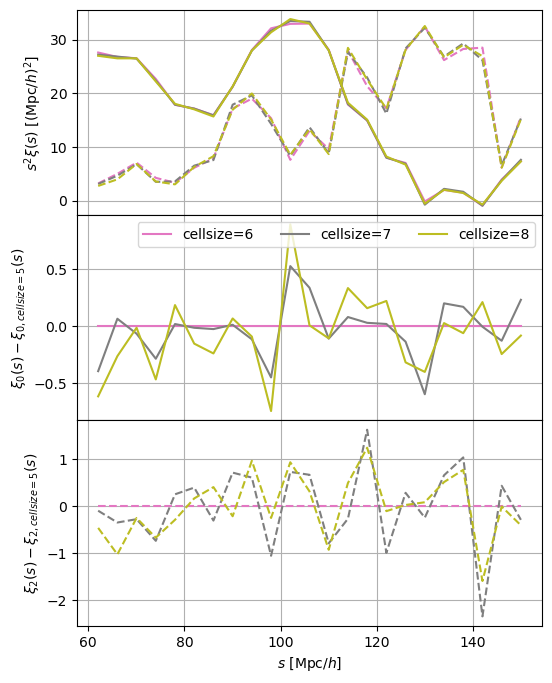

In [85]:
# plot recon correlation function multipoles
fig, axs = plt.subplots(3,1, figsize=(6,8), sharex=True, height_ratios=[1,1,1])
for cellsize in range(6,9):
    zmin, zmax = zbins
    recon_cf_fn = stats_dir / mock_ver / f'recon_particle2_correlation_{tracer}_z{zmin}-{zmax}_{region}_weight-{weight}_cellsize{cellsize}_{imock}.h5'
    corr = types.read(recon_cf_fn)
    print(recon_cf_fn)

    # Rebinning
    corr = corr.select(s=slice(0, None, 4))
    corr = corr.select(s=(60., 150)) 
    
    # To multipoles
    xi = corr.project(ells=[0, 2])
    s = corr.coords('s')

    if cellsize==6:
        poles0 = []
    for i, ell in enumerate(xi.ells):
        pole = xi.get(ell)
        axs[0].plot(s, s*s*pole.value(), color=f'C{cellsize}', linestyle=['-', '--'][i])

        if cellsize==6:
            poles0.append(pole.value())
        axs[i+1].plot(s, s*s*(pole.value()-poles0[i]), color=f'C{cellsize}', linestyle=['-', '--'][i], label=f'cellsize={cellsize}')

axs[0].set_ylabel(r'$s^2 \xi(s)$ [$(\mathrm{Mpc}/h)^2$]')
axs[1].set_ylabel(r'$\xi_0(s)-\xi_{0,cellsize=5}(s)$')
axs[2].set_ylabel(r'$\xi_2(s)-\xi_{2,cellsize=5}(s)$')
axs[2].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
axs[1].legend(ncol=3)
for ax in axs:
    ax.grid()   
plt.subplots_adjust(hspace=0.)

<Axes: xlabel='$s$ [$\\mathrm{Mpc}/h$]', ylabel='$s^{2} \\xi_{\\ell}(s)$ [$(\\mathrm{Mpc}/h)^{2}$]'>

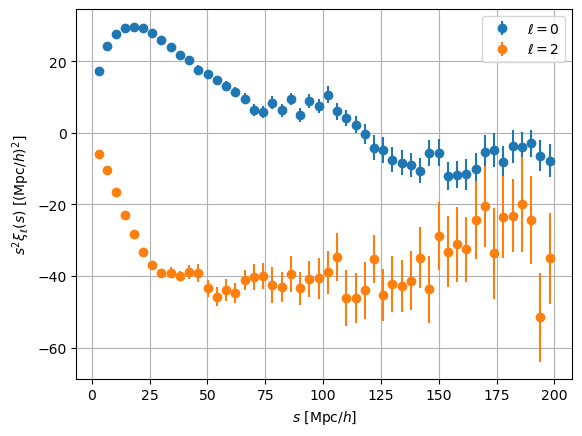

In [78]:
signal_fn = basedir +'/xi/smu/allcounts_ELG_LOPnotqso_NGC_0.8_1.1_default_FKP_lin_njack60_nran4_split20.npy'
from pycorr import TwoPointCorrelationFunction
xi = TwoPointCorrelationFunction.load(signal_fn)
xi.rebin(4)
# s, xi = xi.get_corr(ells=[0, 2], return_sep=True, return_cov=False)
xi.plot(ells=[0, 2])
